# Kiểm tra Chất lượng Dữ liệu Cuối cùng (Final Data Quality Check)

Thực hiện việc nghiệm thu dữ liệu sau **Giai đoạn 1: Xử lý dữ liệu**.
Trước khi đưa dữ liệu vào quá trình huấn luyện mô hình Fine-tuning và RAG, việc xác nhận tính toàn vẹn và sạch sẽ của dữ liệu là bắt buộc nhằm tránh lỗi sập hệ thống huấn luyện hoặc thiên lệch đánh giá.

**Nội dung kiểm tra bao gồm:**
1. **Kiểm tra rò rỉ (Leakage Check)**: Xác nhận sự giao thoa giữa các tập Train, Val, Test bằng 0.
2. **Kiểm tra kiểu dữ liệu (Data Type Check)**: Đảm bảo các cột điểm số ở định dạng số thực (`float`) và không chứa ký tự lạ.
3. **Phân tích ngoại lệ (Outlier Analysis)**: Phát hiện các bài viết quá ngắn hoặc quá dài bất thường.
4. **Bảng tổng kết (Summary Table)**: Thống kê tổng số lượng dòng, cột, và thuộc tính của các tệp tin đầu ra trong thư mục `data/processed/`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Tải Các Tập Dữ liệu Sạch

Đọc 3 tệp dữ liệu sạch từ thư mục `data/processed/`.

In [2]:
DATA_PROCESSED_DIR = "../data/processed"

train_path = os.path.join(DATA_PROCESSED_DIR, "train.csv")
val_path = os.path.join(DATA_PROCESSED_DIR, "val.csv")
test_path = os.path.join(DATA_PROCESSED_DIR, "test.csv")

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

print("Tập dữ liệu đã tải thành công:")
print(f"- Train Set: {df_train.shape[0]} dòng, {df_train.shape[1]} cột")
print(f"- Val Set: {df_val.shape[0]} dòng, {df_val.shape[1]} cột")
print(f"- Test Set: {df_test.shape[0]} dòng, {df_test.shape[1]} cột")

Tập dữ liệu đã tải thành công:
- Train Set: 7460 dòng, 17 cột
- Val Set: 829 dòng, 17 cột
- Test Set: 492 dòng, 17 cột


## 2. Kiểm tra Rò rỉ Dữ liệu (Leakage Validation)

Xác minh chéo xem có bất kỳ bài viết nào trong tập Test xuất hiện lại ở tập Train hoặc tập Val hay không.     
Tương tự, kiểm tra giao thoa giữa tập Train và tập Val.
Mục tiêu là tất cả các phép so khớp giao thoa phải trả về kết quả bằng **0**.

In [3]:
# Chuyển văn bản thành set để so khớp giao lộ
set_train = set(df_train['essay'].unique())
set_val = set(df_val['essay'].unique())
set_test = set(df_test['essay'].unique())

# Tính toán các điểm giao thoa
overlap_train_test = len(set_train.intersection(set_test))
overlap_val_test = len(set_val.intersection(set_test))
overlap_train_val = len(set_train.intersection(set_val))

print("=== KIỂM TRA RÒ RỈ DỮ LIỆU CHÉO (OVERLAP CHECK) ===")
print(f"1. Số lượng bài trùng giữa Train và Test: {overlap_train_test} bài")
print(f"2. Số lượng bài trùng giữa Val và Test  : {overlap_val_test} bài")
print(f"3. Số lượng bài trùng giữa Train và Val  : {overlap_train_val} bài")

print("\n--- ĐÁNH GIÁ CHẤT LƯỢNG ---")
if overlap_train_test == 0 and overlap_val_test == 0 and overlap_train_val == 0:
    print("✔ ĐẠT YÊU CẦU: Không phát hiện bất kỳ sự rò rỉ dữ liệu chéo nào.")
else:
    print("❌ CẢNH BÁO: Phát hiện rò rỉ dữ liệu, vui lòng kiểm tra lại quy trình dọn dẹp.")

=== KIỂM TRA RÒ RỈ DỮ LIỆU CHÉO (OVERLAP CHECK) ===
1. Số lượng bài trùng giữa Train và Test: 0 bài
2. Số lượng bài trùng giữa Val và Test  : 0 bài
3. Số lượng bài trùng giữa Train và Val  : 0 bài

--- ĐÁNH GIÁ CHẤT LƯỢNG ---
✔ ĐẠT YÊU CẦU: Không phát hiện bất kỳ sự rò rỉ dữ liệu chéo nào.


## 3. Kiểm tra Kiểu Dữ liệu và Khoảng Điểm (Data Type & Value Constraints)

Đảm bảo các cột điểm số thành phần và điểm tổng đều ở định dạng số thực (`float` hoặc `int`), không chứa giá trị NaN và nằm trong khoảng điểm chuẩn IELTS [1.0 - 9.0].

In [4]:
score_cols = ['TR_Band', 'CC_Band', 'LR_Band', 'GRA_Band', 'Overall_Band']

def validate_scores(name, df):
    print(f"\n--- Kiểm tra tập: {name} ---")
    for col in score_cols:
        # 1. Kiểm tra kiểu dữ liệu
        is_numeric = pd.api.types.is_numeric_dtype(df[col])
        # 2. Kiểm tra khoảng điểm [1.0 - 9.0]
        min_val = df[col].min()
        max_val = df[col].max()
        # 3. Đếm NaN
        nan_count = df[col].isnull().sum()
        
        status = "OK" if (is_numeric and min_val >= 1.0 and max_val <= 9.0 and nan_count == 0) else "❌ LỖI"
        print(f"Cột {col:12}: Kiểu số = {is_numeric} | Range = [{min_val}, {max_val}] | NaNs = {nan_count} | Trạng thái: {status}")

validate_scores("Train", df_train)
validate_scores("Val", df_val)
validate_scores("Test", df_test)


--- Kiểm tra tập: Train ---
Cột TR_Band     : Kiểu số = True | Range = [1.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột CC_Band     : Kiểu số = True | Range = [2.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột LR_Band     : Kiểu số = True | Range = [2.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột GRA_Band    : Kiểu số = True | Range = [2.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột Overall_Band: Kiểu số = True | Range = [2.0, 9.0] | NaNs = 0 | Trạng thái: OK

--- Kiểm tra tập: Val ---
Cột TR_Band     : Kiểu số = True | Range = [1.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột CC_Band     : Kiểu số = True | Range = [2.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột LR_Band     : Kiểu số = True | Range = [2.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột GRA_Band    : Kiểu số = True | Range = [2.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột Overall_Band: Kiểu số = True | Range = [2.0, 9.0] | NaNs = 0 | Trạng thái: OK

--- Kiểm tra tập: Test ---
Cột TR_Band     : Kiểu số = True | Range = [1.0, 9.0] | NaNs = 0 | Trạng thái: OK
Cột CC_Band   

## 4. Phân tích Giá trị Ngoại lệ về Độ dài (Essay Length Outliers)

Bài luận IELTS Writing Task 2 cần đạt tối thiểu 250 từ. Nếu một bài viết quá ngắn (dưới 100 từ) hoặc quá dài (trên 600 từ), đó là những trường hợp bất thường cần thống kê.

Tập Train: Tổng số mẫu = 7460
  - Quá ngắn (< 100 từ): 77 mẫu (1.03%)
  - Quá dài  (> 600 từ): 1 mẫu (0.01%)
Tập Val  : Tổng số mẫu = 829
  - Quá ngắn (< 100 từ): 8 mẫu (0.97%)
  - Quá dài  (> 600 từ): 1 mẫu (0.12%)
Tập Test : Tổng số mẫu = 492
  - Quá ngắn (< 100 từ): 7 mẫu (1.42%)
  - Quá dài  (> 600 từ): 0 mẫu (0.00%)


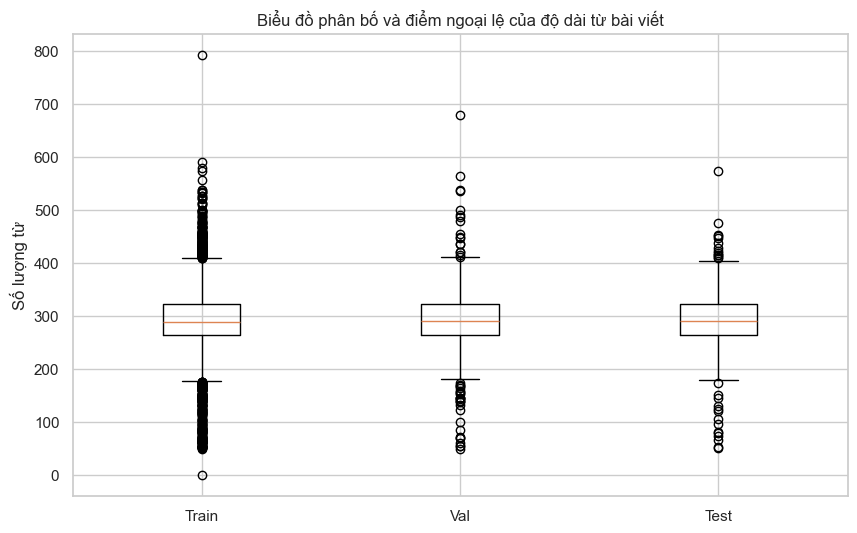

In [5]:
# Tính toán độ dài từ cho cả 3 tập dữ liệu
df_train['word_count'] = df_train['essay'].apply(lambda x: len(str(x).split()))
df_val['word_count'] = df_val['essay'].apply(lambda x: len(str(x).split()))
df_test['word_count'] = df_test['essay'].apply(lambda x: len(str(x).split()))

MIN_WORDS_LIMIT = 100
MAX_WORDS_LIMIT = 600

def print_outliers_info(name, df):
    too_short = df[df['word_count'] < MIN_WORDS_LIMIT]
    too_long = df[df['word_count'] > MAX_WORDS_LIMIT]
    total = len(df)
    print(f"Tập {name:5}: Tổng số mẫu = {total}")
    print(f"  - Quá ngắn (< {MIN_WORDS_LIMIT} từ): {len(too_short)} mẫu ({len(too_short)/total*100:.2f}%)")
    print(f"  - Quá dài  (> {MAX_WORDS_LIMIT} từ): {len(too_long)} mẫu ({len(too_long)/total*100:.2f}%)")

print_outliers_info("Train", df_train)
print_outliers_info("Val", df_val)
print_outliers_info("Test", df_test)

# Vẽ Boxplot độ dài bài viết
plt.figure(figsize=(10, 6))
all_lens = [df_train['word_count'], df_val['word_count'], df_test['word_count']]
plt.boxplot(all_lens, tick_labels=['Train', 'Val', 'Test'])
plt.title('Biểu đồ phân bố và điểm ngoại lệ của độ dài từ bài viết')
plt.ylabel('Số lượng từ')
plt.show()

## 5. Bảng Tổng kết Nghiệm thu dữ liệu

Hiển thị bảng tổng kết số lượng dòng của từng tệp tin trong `data/processed/` sau khi đã kết thúc Giai đoạn 1.

In [6]:
summary_data = []

for filename, df in [("train.csv", df_train),
                     ("val.csv", df_val),
                     ("test.csv", df_test)]:
    summary_data.append({
        'Tên file': filename,
        'Số dòng': df.shape[0],
        'Số cột': df.shape[1],
        'Số bài viết độc bản': df['essay'].nunique(),
        'Tổng số NaNs': df.isnull().sum().sum()
    })

# Thêm RAG Knowledge Base để đối chiếu
rag_kb_path = os.path.join(DATA_PROCESSED_DIR, "rag_knowledge_base.csv")
if os.path.exists(rag_kb_path):
    df_rag = pd.read_csv(rag_kb_path)
    summary_data.append({
        'Tên file': "rag_knowledge_base.csv",
        'Số dòng': df_rag.shape[0],
        'Số cột': df_rag.shape[1],
        'Số bài viết độc bản': df_rag['essay'].nunique(),
        'Tổng số NaNs': df_rag.isnull().sum().sum()
    })

df_summary = pd.DataFrame(summary_data)
print("=== BẢNG TỔNG KẾT THÔNG SỐ NGHIỆM THU DỮ LIỆU ===")
print(df_summary.to_string(index=False))

=== BẢNG TỔNG KẾT THÔNG SỐ NGHIỆM THU DỮ LIỆU ===
              Tên file  Số dòng  Số cột  Số bài viết độc bản  Tổng số NaNs
             train.csv     7460      18                 7460           138
               val.csv      829      18                  829            33
              test.csv      492      18                  492            18
rag_knowledge_base.csv     7460      17                 7460           138
